# Project 01 (basic) — Point operations & histogram equalization

**Module 12 — Image Processing** · Format: **Jupyter notebook** (`point_ops_histogram.ipynb`)

The simplest image operations are **point operations**: every pixel is recomputed
*independently* of its neighbours. Despite their simplicity they are behind brightness,
contrast, gamma and **histogram equalization** — one of the nicest small algorithms of image
processing. Here you build them by hand and make their effect visible on the histogram.

Core questions (script section 1):
- How do linear point operations and **gamma** change an image?
- What does the **histogram** describe, and how does the **equalization via the CDF** stretch
  the contrast?

> **Plenty of instruction, no training, only `numpy`.** Runs in seconds.


## Setup

Requires `numpy`, `matplotlib`, `Pillow` (repo `requirements.txt`). The example image
(*Grace Hopper*) is included in matplotlib — no download.

```bash
source ../../../../.venv/bin/activate
jupyter lab      # or open the notebook in VS Code, kernel = repo .venv
```


## Part A — Image & histogram *(given)*

We load a grayscale image (values $0$–$255$) and show it with its **histogram** — the
distribution of the gray values.


Image: (600, 512) dtype uint8 min/max 0 255


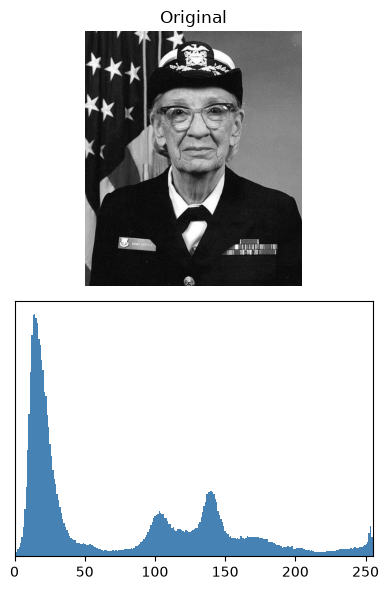

In [1]:
# ---- Image + histogram (given) -------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from PIL import Image

with cbook.get_sample_data("grace_hopper.jpg") as f:
    img = np.asarray(Image.open(f).convert("L"), dtype=np.uint8)   # grayscale 0..255
print("Image:", img.shape, "dtype", img.dtype, "min/max", img.min(), img.max())

def show_with_hist(images, titles):
    n = len(images)
    fig, ax = plt.subplots(2, n, figsize=(4 * n, 6))
    ax = np.array(ax).reshape(2, n)          # a 2D axis matrix even for n=1
    for k, (im, t) in enumerate(zip(images, titles)):
        ax[0, k].imshow(im, cmap="gray", vmin=0, vmax=255); ax[0, k].set_title(t); ax[0, k].axis("off")
        ax[1, k].hist(im.ravel(), bins=256, range=(0, 255), color="steelblue")
        ax[1, k].set_xlim(0, 255); ax[1, k].set_yticks([])
    plt.tight_layout(); plt.show()

show_with_hist([img], ["Original"])

### Task 1 — Linear point operation & gamma

Implement two point operations $s=T(r)$ (script 1.2). Mind the **clipping** to $[0,255]$ and
`uint8`.

- **Linear** (contrast $a$, brightness $b$): $s = a\,r + b$.
- **Gamma:** $s = 255\,(r/255)^{\gamma}$ — $\gamma<1$ brightens dark areas.

**Your task (`# TODO`):** fill in `linear(img, a, b)` and `gamma(img, g)`.


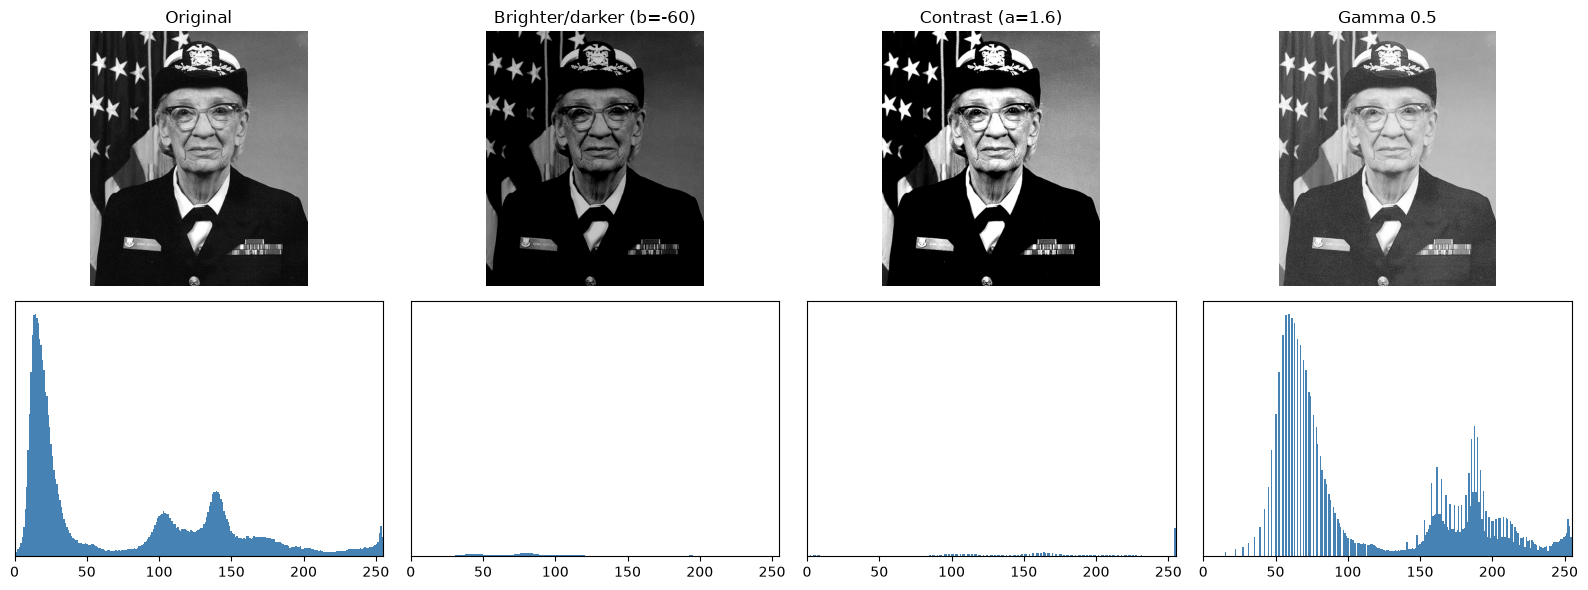

In [2]:
# ---- TASK 1: point operations --------------------------------------------
def linear(im, a, b):
    out = a * im.astype(np.float32) + b
    return np.clip(out, 0, 255).astype(np.uint8)

def gamma(im, g):
    out = 255.0 * (im.astype(np.float32) / 255.0) ** g
    return np.clip(out, 0, 255).astype(np.uint8)

dark = linear(img, 1.0, -60)          # darker
contr = linear(img, 1.6, -60)         # higher contrast
g_bright = gamma(img, 0.5)            # dark areas brightened

show_with_hist([img, dark, contr, g_bright],
               ["Original", "Brighter/darker (b=-60)", "Contrast (a=1.6)", "Gamma 0.5"])

### Task 2 — Histogram equalization by hand

**Histogram equalization** uses the **cumulative distribution** (CDF) as the mapping
(script 1.3):
$$s = T(r) = \operatorname{round}\!\big((L-1)\cdot \text{cdf}(r)\big),\quad L=256.$$

**Your task (`# TODO`):** implement `equalize(img)`:
1. the histogram of the 256 gray values (`np.bincount(im.ravel(), minlength=256)`);
2. normalize to $p(k)$, accumulate to the `cdf`;
3. the mapping `T = round(255 * cdf)` (as `uint8`), then apply `T[img]`.


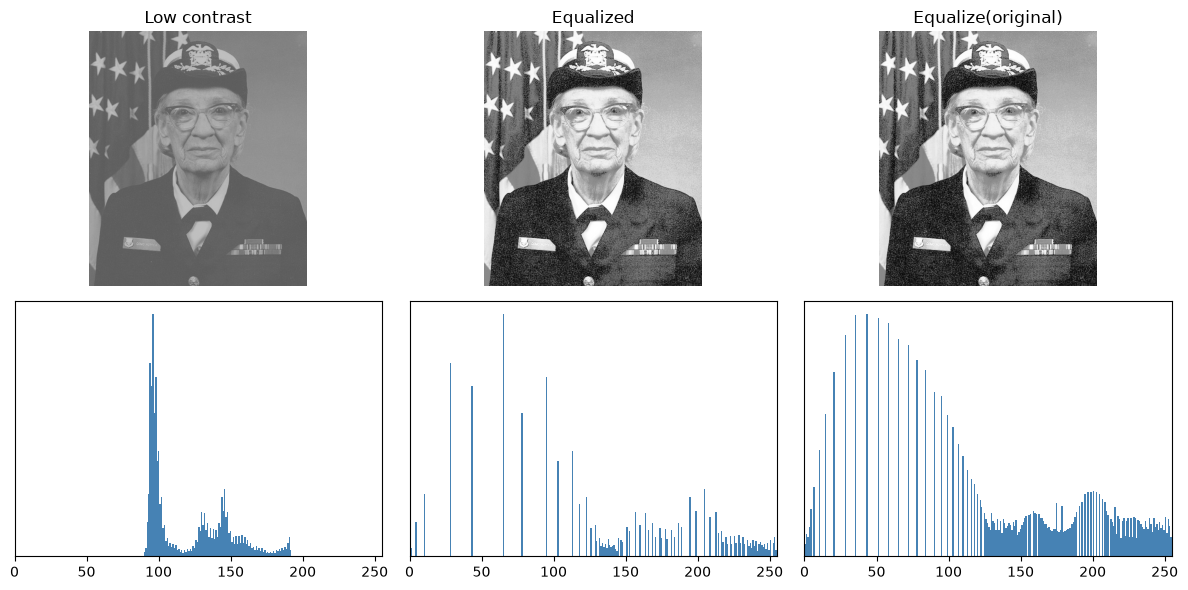

In [3]:
# ---- TASK 2: histogram equalization --------------------------------------
def equalize(im):
    hist = np.bincount(im.ravel(), minlength=256).astype(np.float64)
    cdf = np.cumsum(hist) / hist.sum()           # cumulative distribution in [0,1]
    T = np.round(255 * cdf).astype(np.uint8)     # mapping table
    return T[im]

# create a low-contrast image (compress into a narrow range), then equalize
low_contrast = linear(img, 0.4, 90)
equalized = equalize(low_contrast)
show_with_hist([low_contrast, equalized, equalize(img)],
               ["Low contrast", "Equalized", "Equalize(original)"])

### Task 3 — Make the CDF visible & self-check

**Your task (`# TODO`):** plot the **CDF** of the low-contrast image before and after
equalization. After equalization the CDF should be **approximately a straight line** (the
diagonal) — that is the graphical signature of the uniform distribution.


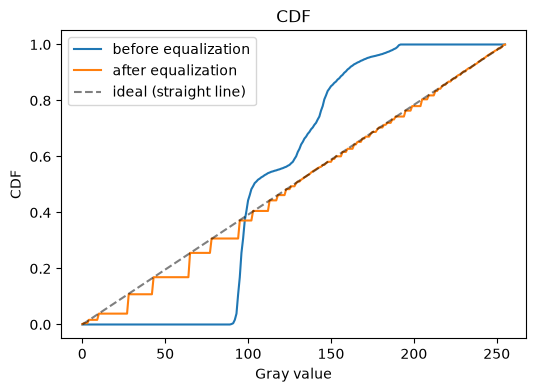

Value range low contrast: 90 - 192
Value range equalized: 0 - 255


In [4]:
# ---- TASK 3: CDF before/after equalization -------------------------------
def cdf_of(im):
    h = np.bincount(im.ravel(), minlength=256).astype(np.float64)
    return np.cumsum(h) / h.sum()

plt.figure(figsize=(6, 4))
plt.plot(cdf_of(low_contrast), label="before equalization")
plt.plot(cdf_of(equalized), label="after equalization")
plt.plot([0, 255], [0, 1], "k--", alpha=0.5, label="ideal (straight line)")
plt.xlabel("Gray value"); plt.ylabel("CDF"); plt.legend(); plt.title("CDF"); plt.show()

# self-check: equalization uses (almost) the full value range
print("Value range low contrast:", low_contrast.min(), "-", low_contrast.max())
print("Value range equalized:", equalized.min(), "-", equalized.max())

## Reflection — reference answers

1. **Gamma.** On the normalized range $[0,1]$ the curve $x^\gamma$ with $\gamma<1$ lies
   *above* the diagonal, and the gap $x^\gamma-x$ is largest for small $x$ and shrinks towards
   $x=1$. So a dark pixel (small $r/255$) is lifted by a large amount, while a bright pixel
   (near 1) barely moves — the mapping is steep near 0 and flat near 255. That is exactly why
   $\gamma<1$ brightens the shadows strongly while leaving the highlights almost untouched
   (and $\gamma>1$ does the opposite).

2. **Equalization.** The CDF mapping $s=(L-1)\cdot\text{cdf}(r)$ assigns each intensity an
   output proportional to *how many pixels are darker than it*. Where many pixels are bunched
   together (a tall histogram peak) the CDF rises steeply, so those intensities are pulled
   *apart* (mapped to a wide output span); where few pixels sit (a flat part) the CDF is
   shallow and those intensities are squeezed together. Spreading dense regions and compressing
   sparse ones is precisely what turns the distribution into an approximately uniform one — and
   a uniform histogram has a *linear* CDF, so the after-CDF is close to the diagonal. (It is
   only approximate because the gray values are discrete and equal-valued pixels cannot be
   split.)

3. **Limits.** Because global equalization uses a *single* mapping for the whole image, a
   scene with both very dark and very bright regions gets one compromise curve that can wash
   out or overdrive local contrast. **Adaptive** methods fix this by equalizing *per region*:
   **CLAHE** (contrast-limited adaptive histogram equalization) computes a separate histogram
   for each small tile, *clips* the histogram peaks to limit noise amplification, and
   interpolates between tiles to avoid seams — so contrast is enhanced locally without one
   region's statistics dominating another's.

4. **Point operations.** A point operation is by definition a function $s=T(r)$ of the single
   pixel value alone — it has no access to the neighbours. Removing noise or sharpening edges
   requires comparing a pixel with its *surroundings* (averaging out a noisy pixel, or
   detecting a local intensity change), which is inherently a *neighbourhood* operation. That
   is what **filtering / convolution** provides (a weighted combination of neighbouring
   pixels), and it is the subject of project 02 (spatial and frequency-domain filtering).

> **Reference:** after equalization the image uses (almost) the full range 0–255, the
> histogram is wider/flatter, the CDF is close to the diagonal. Gamma 0.5 visibly lifts shadow
> detail.
